In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import t, f, norm, rankdata
from statsmodels.stats.diagnostic import lilliefors

n = 50
np.random.seed(42) 

# Генерация независимых переменных
xi1 = np.random.uniform(-1, 1, n)
xi2 = np.random.uniform(-1, 1, n)
xi3 = np.random.uniform(-1, 1, n)
xi4 = np.random.uniform(-1, 1, n)
xi5 = np.random.uniform(-1, 1, n)

# Генерация зависимой переменной
eta_mean = 2 + 3*xi1 - 2*xi2 + xi3 + xi4 - xi5
eta = np.random.normal(eta_mean, 1.5, n)

# Сборка в DataFrame
data = pd.DataFrame({
    'ξ1': xi1, 'ξ2': xi2, 'ξ3': xi3, 'ξ4': xi4, 'ξ5': xi5, 'η': eta
})

print("Первые 5 строк сгенерированной выборки:")
display(data.head())

Первые 5 строк сгенерированной выборки:


,ξ1,ξ2,ξ3,ξ4,ξ5,η
0,-0.250920,0.939169,-0.937142,0.816532,0.284063,-2.305962
1,0.901429,0.550266,0.272821,-0.520876,-0.831720,1.915148
2,0.463988,0.878998,-0.371288,-0.710210,-0.676743,0.559440
3,0.197317,0.789655,0.017141,-0.021094,0.797108,1.496178
4,-0.687963,0.195800,0.815133,0.971301,0.212858,1.439228


In [2]:
X = data[['ξ1', 'ξ2', 'ξ3', 'ξ4', 'ξ5']]

print("Проверка на мультиколлинеарность:")
for k in range(1, 6):
    target = f'ξ{k}'
    predictors = sm.add_constant(X.drop(target, axis=1))
    model_mult = sm.OLS(X[target], predictors).fit()
    print(f"R² для {target}: {model_mult.rsquared:.3f}")

Проверка на мультиколлинеарность:
R² для ξ1: 0.018
R² для ξ2: 0.015
R² для ξ3: 0.065
R² для ξ4: 0.116
R² для ξ5: 0.080


In [3]:
PSI = sm.add_constant(X)

model = sm.OLS(data['η'], PSI).fit()
print(f"Уравнение регрессии:\n{model.params}\n")

F_mat = PSI.T @ PSI
F_inv = np.linalg.inv(F_mat)
RSS = model.ssr
print(f"RSS: {RSS:.4f}\n")

# Проверка значимости коэфф. регрессии 
labels = ['const', 'ξ1', 'ξ2', 'ξ3', 'ξ4', 'ξ5']
sign_df_data = []

for k in range(len(labels)):
    delta_val = model.params.iloc[k] * np.sqrt(model.df_resid) / np.sqrt(RSS * F_inv[k][k])
    p_value = 2 * t.sf(np.abs(delta_val), model.df_resid)
    
    is_sign = 'Да' if p_value < 0.05 else 'Нет'
    sign_df_data.append([labels[k], delta_val, p_value, is_sign])

sign_df = pd.DataFrame(sign_df_data, columns=['Параметр', 'T-статистика', 'P-value', 'Значим?'])
display(sign_df)

Уравнение регрессии:
const    2.038618
ξ1       2.172270
ξ2      -1.843336
ξ3       1.662206
ξ4       1.040171
ξ5      -1.144425
dtype: float64

RSS: 111.3690



,Параметр,T-статистика,P-value,Значим?
0,const,8.846495,2.541680e-11,Да
1,ξ1,5.473441,1.991828e-06,Да
2,ξ2,-4.939430,1.177421e-05,Да
3,ξ3,4.207229,1.251552e-04,Да
4,ξ4,2.498995,1.626059e-02,Да
5,ξ5,-2.986238,4.601569e-03,Да


In [4]:
print(f"Коэффициент детерминации (R²): {model.rsquared:.4f}")

# значимость всей регрессии
k_vars = len(labels) - 1 
F_stat = (model.centered_tss - RSS) * model.df_resid / (RSS * k_vars)
p_value_f = f.sf(F_stat, k_vars, model.df_resid)

print(f"F-статистика: {F_stat:.4f}")
print(f"P-value: {p_value_f:.2e}")

if p_value_f < 0.05:
    print("Вывод: Регрессия значима.")
else:
    print("Вывод: Регрессия незначима.")

Коэффициент детерминации (R²): 0.6444
F-статистика: 15.9483
P-value: 5.97e-09
Вывод: Регрессия значима.


In [5]:
X_0 = np.array([1, 0, 0, 0, 0, 0])

# Точечная оценка y 
y_point = np.sum(model.params * X_0)

t_crit = t.ppf(1 - 0.05/2, model.df_resid)
margin_of_error = t_crit * np.sqrt(1 + X_0 @ F_inv @ X_0.T) * np.sqrt(RSS / model.df_resid)

lower_bound = y_point - margin_of_error
upper_bound = y_point + margin_of_error

print(f"Значение в точке x=0: {y_point:.4f}")
print(f"95% Доверительный интервал: ({lower_bound:.4f}, {upper_bound:.4f})")

Значение в точке x=0: 2.0386
95% Доверительный интервал: (-1.2012, 5.2784)


In [6]:
e = model.resid


def count_inversions(arr):
    ranks = rankdata(arr, method='average')
    inv_count = 0
    
    for i in range(len(ranks)):
        inv_count += np.sum(ranks[i+1:] < ranks[i])
        
    return int(inv_count)


inv_amount = count_inversions(e)
E_A = n * (n - 1) / 4
Var_A = (n**3) / 36

delta_inv = (inv_amount - E_A) / np.sqrt(Var_A)
p_value_inv = 2 * norm.sf(np.abs(delta_inv), 0, 1)

print(f"Статистика критерия инверсий: {delta_inv:.4f}")  
print(f"P-value: {p_value_inv:.4f}")

if p_value_inv < 0.05:
    print('Вывод: Отвергаем H₀. Ошибки зависимы.')
else:
    print('Вывод: Нет оснований отвергать H₀. Ошибки измерения независимы.')

Статистика критерия инверсий: -0.5855
P-value: 0.5582
Вывод: Нет оснований отвергать H₀. Ошибки измерения независимы.


In [7]:
e_sorted = np.sort(model.resid.values)
F_emp = np.arange(n + 1) / n

# Оценка стандартного отклонения остатков
sigma_est = np.sqrt(RSS / model.df_resid)

# статистика Колмогорова-Смирнова
def calc_ks_stat(sample, mean, std):
    theo_cdf = norm.cdf(sample, loc=mean, scale=std)
    diff_left = np.abs(theo_cdf - F_emp[:-1])
    diff_right = np.abs(theo_cdf - F_emp[1:])
    
    return np.sqrt(n) * np.max(np.maximum(diff_left, diff_right))

delta_wave = calc_ks_stat(e_sorted, 0, sigma_est)

bootstrap_iterations = 50_000
bootstrap_delta = np.zeros(bootstrap_iterations)

for i in range(bootstrap_iterations):
    random_sample = np.sort(np.random.normal(0, sigma_est, n))
    
    mean_b = np.mean(random_sample)
    sigma_b = np.std(random_sample, ddof=1)
    
    bootstrap_delta[i] = calc_ks_stat(random_sample, mean_b, sigma_b)

p_value_boot = np.sum(bootstrap_delta >= delta_wave) / bootstrap_iterations

print(f"Статистика Колмогорова-Смирнова (исходная): {delta_wave:.4f}")
print(f"P-value (бутстрап): {p_value_boot:.5f}")

if p_value_boot < 0.05:
    print('Вывод: Отвергаем H₀. Распределение остатков отличается от нормального.')
else:
    print('Вывод: Нет оснований отвергать H₀. Ошибки распределены нормально.')

Статистика Колмогорова-Смирнова (исходная): 0.6442
P-value (бутстрап): 0.37212
Вывод: Нет оснований отвергать H₀. Ошибки распределены нормально.


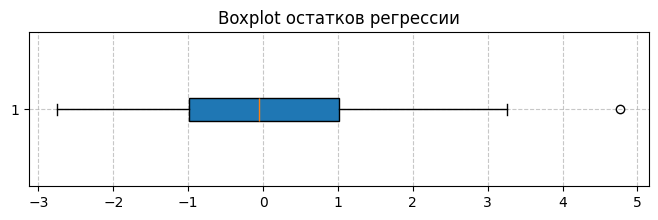

In [8]:
plt.figure(figsize=(8, 2))
plt.boxplot(e, vert=False, patch_artist=True, showfliers=True)
plt.title('Boxplot остатков регрессии')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [9]:
CVSS = 0
for i in range(n):
    train_x = sm.add_constant(data.drop(i))[labels]
    train_y = data.drop(i)['η']

    test_x = sm.add_constant(data)[labels].iloc[i]
    test_y = data['η'].iloc[i]

    # Обучение и предсказание
    model_cv = sm.OLS(train_y, train_x).fit()
    y_pred = np.dot(model_cv.params, test_x)

    # Накопление ошибки
    CVSS += (y_pred - test_y) ** 2

R2_cv = 1 - (CVSS / model.centered_tss)

print(f"CVSS: {CVSS:.4f}")
print(f"R² кросс-валидации: {R2_cv:.4f}")

CVSS: 145.9261
R² кросс-валидации: 0.5341


In [10]:
l = 5
# Делаем l измерений в точке x = 0 (где мат. ожидание = 2)
eta_repeated = np.random.normal(2, 1.5, l)

y_mean_repeated = np.mean(eta_repeated)
sigma_sq_pure_error = np.sum((eta_repeated - y_mean_repeated) ** 2) / (l - 1)

# Сравнение дисперсии остатков и дисперсии чистой ошибки
F_stat_adeq = (RSS / model.df_resid) / sigma_sq_pure_error
p_value_adeq = f.sf(F_stat_adeq, model.df_resid, l - 1)

print(f"F-статистика: {F_stat_adeq:.4f}")
print(f"P-value: {p_value_adeq:.4f}")

if p_value_adeq < 0.05:
    print('Вывод: Модель не адекватна.')
else:
    print('Вывод: Модель адекватна.')

F-статистика: 0.7440
P-value: 0.7312
Вывод: Модель адекватна.


In [11]:
# Ищем признак с максимальным p-value
p_values = model.pvalues.drop('const')
least_sign_var = p_values.idxmax()

print(f"Наименее значимая переменная: {least_sign_var} (p-value = {p_values[least_sign_var]:.4f}). Удаляем её.\n")

# Строим новую (усеченную) модель
labels_dim = [col for col in labels if col != least_sign_var]
PSI_dim = sm.add_constant(data[[col for col in labels_dim if col != 'const']])

model_dim = sm.OLS(data['η'], PSI_dim).fit()
RSS_dim = model_dim.ssr

print("Параметры новой модели:")
print(model_dim.params)
print(f"\nRSS новой модели: {RSS_dim:.4f}")
print(f"R² новой модели: {model_dim.rsquared:.4f}\n")

# Сравнение вложенных моделей (проверка гипотезы о том, что удаленный коэфф равен 0)
df_diff = model_dim.df_resid - model.df_resid
F_stat_nested = ((RSS_dim - RSS) / df_diff) / (RSS / model.df_resid)
p_value_nested = f.sf(F_stat_nested, df_diff, model.df_resid)

print(f"F-тест сравнения моделей (Дельта): {F_stat_nested:.4f}")
print(f"P-value сравнения: {p_value_nested:.4f}")

if p_value_nested < 0.05:
    print('Вывод: Отвергаем H₀. Удаление переменной значимо ухудшило модель.')
else:
    print('Вывод: Нет оснований отвергать H₀. Модели статистически не различаются (можно использовать усеченную).')

Наименее значимая переменная: ξ4 (p-value = 0.0163). Удаляем её.

Параметры новой модели:
const    2.059895
ξ1       2.187651
ξ2      -1.831934
ξ3       1.473293
ξ5      -0.881604
dtype: float64

RSS новой модели: 127.1757
R² новой модели: 0.5940

F-тест сравнения моделей (Дельта): 6.2450
P-value сравнения: 0.0163
Вывод: Отвергаем H₀. Удаление переменной значимо ухудшило модель.


In [12]:
n_iterations = 1000
alpha = 0.05 

# Точечная оценка разности R^2 по исходной выборке
h_wave = model.rsquared - model_dim.rsquared
bootstrap_delta = []

for _ in range(n_iterations):
    sample = sm.add_constant(data.sample(n=n, replace=True))
    
    b_model = sm.OLS(sample['η'], sample[labels]).fit()
    b_model_dim = sm.OLS(sample['η'], sample[labels_dim]).fit()
    
    diff_bootstrap = (b_model.rsquared - b_model_dim.rsquared) - h_wave
    bootstrap_delta.append(diff_bootstrap)

variation_row = sorted(bootstrap_delta)

idx_lower = int((alpha / 2) * n_iterations)
idx_upper = int((1 - alpha / 2) * n_iterations)

ci_lower = h_wave - variation_row[idx_upper]
ci_upper = h_wave - variation_row[idx_lower]

print(f"Разность R² на исходной выборке: {h_wave:.4f}")
print(f"95% Доверительный интервал бутстрапа: ({ci_lower:.4f}, {ci_upper:.4f})")

if ci_lower <= 0 <= ci_upper:
    print("Вывод: Различие незначимо.")
else:
    print("Вывод: Различие значимо.")

Разность R² на исходной выборке: 0.0505
95% Доверительный интервал бутстрапа: (-0.0689, 0.0999)
Вывод: Различие незначимо.
